# 07 - Evaluation
On the same-agency pool

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer as _TV



In [32]:
df = pd.read_parquet('00_data/05_sa.parquet')
y  = df['label'].values

idx = np.arange(len(df))
trainval_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)

df_tr = df.iloc[trainval_idx]
df_te = df.iloc[test_idx]
y_tr = y[trainval_idx]
y_te = y[test_idx]

print(f'total: {len(df):,}, trainVal: {len(df_tr):,}, test: {len(df_te):,}')
print(f'positive rate — train: {y_tr.mean():.3f}, test: {y_te.mean():.3f}')


total: 2,514, trainVal: 2,011, test: 503
positive rate — train: 0.522, test: 0.523


In [33]:
flagged_cols = [
    'total_flagged_terms_total', 'unique_flagged_words_total',
    'total_pen_terms_abstract', 'total_nyt_terms_abstract',
    'has_flagged_word_total', 'avg_repetition', 'flagged_ratio',
]
text_prop_cols = ['desc_length', 'title_length', 'desc_word_count']
engagement_cols = ['popularity', 'n_keywords']
completeness_cols = ['has_license', 'has_periodicity', 'has_landing_page', 'org_type_federal']
org_cat_cols = ['org_type']
access_cat_cols = ['dcat_access_level']

all_meta_num = flagged_cols + text_prop_cols + engagement_cols + completeness_cols
all_meta_cat = org_cat_cols + access_cat_cols
input_cols = ['all_text'] + all_meta_num + all_meta_cat

all_meta_num = [c for c in all_meta_num if c in df.columns]
all_meta_cat = [c for c in all_meta_cat if c in df.columns]
input_cols = [c for c in input_cols if c in df.columns]

## Baselines again

In [34]:
def _lr():
    return LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000,
                               class_weight='balanced', C=1.0, random_state=42)

In [35]:
b1 = DummyClassifier(strategy='most_frequent', random_state=42)
b1.fit(np.zeros((len(df_tr), 1)), y_tr)
y_prob_majority = b1.predict_proba(np.zeros((len(df_te), 1)))[:, 1]

In [36]:
b2 = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), _lr())
b2.fit(df_tr[['flagged_ratio']], y_tr)
y_prob_keyword = b2.predict_proba(df_te[['flagged_ratio']])[:, 1]

/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [37]:
b3 = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                               sublinear_tf=True, stop_words='english')),
    ('lr', _lr()),
])
b3.fit(df_tr['all_text'], y_tr)
y_prob_tfidf = b3.predict_proba(df_te['all_text'])[:, 1]

/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [38]:
def parse_emb(series):
    v = series.iloc[0]
    if isinstance(v, (list, np.ndarray)):
        return np.array(series.tolist(), dtype=np.float32)
    return np.vstack(series.apply(lambda x: np.fromstring(
        str(x).strip()[1:-1].replace('\n', ' '), sep=' ', dtype=np.float32)).values)

title_embs = parse_emb(df['title_embeddings_nomic'])
desc_embs = parse_emb(df['desc_embeddings_nomic'])
X_emb = np.hstack([title_embs, desc_embs])

b4 = make_pipeline(StandardScaler(), _lr())
b4.fit(X_emb[trainval_idx], y_tr)
y_prob_emb = b4.predict_proba(X_emb[test_idx])[:, 1]

/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [39]:
t = [('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                                sublinear_tf=True, stop_words='english'), 'all_text')]
if all_meta_num:
    t.append(('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), all_meta_num))
if all_meta_cat:
    t.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), all_meta_cat))

b6 = Pipeline([
    ('pre', ColumnTransformer(t, remainder='drop', sparse_threshold=0)),
    ('lr', _lr()),
])
b6.fit(df_tr[input_cols], y_tr)
y_prob_tfidf_meta = b6.predict_proba(df_te[input_cols])[:, 1]

/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [45]:
threshold = 0.5
qual_cols = [c for c in ['title', 'description', 'all_text', 'org_type', 'org_name',
                          'dcat_access_level', 'flagged_ratio', 'total_flagged_terms_total',
                          'has_flagged_word_total', 'desc_length', 'title_length',
                          'has_license', 'has_periodicity', 'has_landing_page',
                          'popularity', 'n_keywords'] if c in df_te.columns]

eval_df = df_te[qual_cols].copy()
eval_df['y_true'] = y_te

for name, probs in [('majority', y_prob_majority), ('keyword', y_prob_keyword),
                    ('tfidf', y_prob_tfidf), ('emb', y_prob_emb),
                    ('tfidf_meta', y_prob_tfidf_meta)]:
    eval_df[f'y_prob_{name}'] = probs
    eval_df[f'y_pred_{name}'] = (probs >= threshold).astype(int)
    eval_df[f'error_{name}']  = np.where(
        (eval_df['y_true']==1) & (eval_df[f'y_pred_{name}']==1), 'TP',
        np.where((eval_df['y_true']==0) & (eval_df[f'y_pred_{name}']==0), 'TN',
        np.where((eval_df['y_true']==0) & (eval_df[f'y_pred_{name}']==1), 'FP', 'FN')))

VARIANTS = [('TF-IDF', 'tfidf'), ('Embeddings', 'emb'), ('TF-IDF + Meta', 'tfidf_meta')]

print(f'test: {len(eval_df):,} records  |  positive: {y_te.sum()} ({y_te.mean()*100:.1f}%)')
print(f"{'Model':<14}  {'AUC-PR':>7}  {'ROC AUC':>8}  TP   TN   FP   FN")
for name, probs in [('Majority', y_prob_majority), ('Keyword', y_prob_keyword),
                    ('TF-IDF', y_prob_tfidf), ('Embeddings', y_prob_emb),
                    ('TF-IDF+Meta', y_prob_tfidf_meta)]:
    key = name.lower().replace('-','').replace('+','').replace(' ','_').replace('meta','').rstrip('_')

    kmap = {'majority':'majority','keyword':'keyword','tf_idf':'tfidf','embeddings':'emb','tf_idmeta':'tfidf_meta'}
    k2 = {'Majority':'majority','Keyword':'keyword','TF-IDF':'tfidf','Embeddings':'emb','TF-IDF+Meta':'tfidf_meta'}[name]
    c = eval_df[f'error_{k2}'].value_counts()
    aucpr = average_precision_score(y_te, probs)
    auc = roc_auc_score(y_te, probs)
    print(f"  {name:<12}  {aucpr:>7.4f}  {auc:>8.4f}  {c.get('TP',0):>3}  {c.get('TN',0):>3}  {c.get('FP',0):>3}  {c.get('FN',0):>3}")


test: 503 records  |  positive: 263 (52.3%)
Model            AUC-PR   ROC AUC  TP   TN   FP   FN
  Majority       0.5229    0.5000  263    0  240    0
  Keyword        0.5630    0.5260   60  196   44  203
  TF-IDF         0.9146    0.9099  212  211   29   51
  Embeddings     0.8563    0.8847  225  193   47   38
  TF-IDF+Meta    0.8847    0.9039  213  205   35   50


## 2. Classification overview

In [46]:
for name, key in VARIANTS:
    print(f'{name}')
    print(classification_report(eval_df['y_true'], eval_df[f'y_pred_{key}'],
                                 target_names=['non-DRP', 'DRP']))


TF-IDF
              precision    recall  f1-score   support

     non-DRP       0.81      0.88      0.84       240
         DRP       0.88      0.81      0.84       263

    accuracy                           0.84       503
   macro avg       0.84      0.84      0.84       503
weighted avg       0.84      0.84      0.84       503

Embeddings
              precision    recall  f1-score   support

     non-DRP       0.84      0.80      0.82       240
         DRP       0.83      0.86      0.84       263

    accuracy                           0.83       503
   macro avg       0.83      0.83      0.83       503
weighted avg       0.83      0.83      0.83       503

TF-IDF + Meta
              precision    recall  f1-score   support

     non-DRP       0.80      0.85      0.83       240
         DRP       0.86      0.81      0.83       263

    accuracy                           0.83       503
   macro avg       0.83      0.83      0.83       503
weighted avg       0.83      0.83      0.8

In [47]:
counts = pd.DataFrame({
    name: eval_df[f'error_{key}'].value_counts()
    for name, key in VARIANTS
}).fillna(0).astype(int)
print(counts)


    TF-IDF  Embeddings  TF-IDF + Meta
FN      51          38             50
FP      29          47             35
TN     211         193            205
TP     212         225            213


## 3. False positives and false negatives

In [13]:
SHOW = [c for c in ['org_type', 'dcat_access_level', 'y_true',
                     'y_prob_tfidf', 'y_prob_emb', 'y_prob_tfidf_meta',
                     'flagged_ratio', 'total_flagged_terms_total'] if c in eval_df.columns]

fp = eval_df[eval_df['error_tfidf_meta'] == 'FP'].sort_values('y_prob_tfidf_meta', ascending=False)
fn = eval_df[eval_df['error_tfidf_meta'] == 'FN'].sort_values('y_prob_tfidf_meta', ascending=True)
tp = eval_df[eval_df['error_tfidf_meta'] == 'TP'].sort_values('y_prob_tfidf_meta', ascending=False)
tn = eval_df[eval_df['error_tfidf_meta'] == 'TN'].sort_values('y_prob_tfidf_meta', ascending=True)

print(f'FP: {len(fp)}  |  FN: {len(fn)}  |  TP: {len(tp)}  |  TN: {len(tn)}')


FP: 35  |  FN: 50  |  TP: 213  |  TN: 205


### False positives (tfidf_meta model)

In [48]:
fp[SHOW].head(20)


,org_type,dcat_access_level,y_true,y_prob_tfidf,y_prob_emb,y_prob_tfidf_meta,flagged_ratio,total_flagged_terms_total
843,Federal Government,public,0,0.410962,0.001192,0.999992,0.002141,1
198,Federal Government,public,0,0.268470,0.000003,0.953903,0.000000,0
1932,Federal Government,public,0,0.705250,0.999993,0.913842,0.102564,8
1985,Federal Government,public,0,0.894303,0.999693,0.900156,0.000000,0
787,Federal Government,public,0,0.871421,0.997771,0.877853,0.000000,0
1778,Federal Government,public,0,0.881580,0.999888,0.875094,0.000000,0
836,Federal Government,public,0,0.874710,0.889678,0.869412,0.000000,0
452,Federal Government,public,0,0.847796,0.636550,0.849963,0.000000,0
384,Federal Government,public,0,0.829446,0.072055,0.823089,0.000000,0
2363,Federal Government,public,0,0.816776,0.999987,0.814778,0.000000,0


In [49]:
print('FP by org_type:')
print(fp['org_type'].value_counts())
print()
print('FP flagged_ratio vs TN flagged_ratio:')
print(pd.DataFrame({'FP': fp['flagged_ratio'].describe(),
                    'TN': tn['flagged_ratio'].describe()}).round(4))


FP by org_type:
org_type
Federal Government    35
Name: count, dtype: int64

FP flagged_ratio vs TN flagged_ratio:
            FP        TN
count  35.0000  205.0000
mean    0.0222    0.0071
std     0.0725    0.0214
min     0.0000    0.0000
25%     0.0000    0.0000
50%     0.0000    0.0000
75%     0.0070    0.0000
max     0.4000    0.2000


In [50]:
for _, row in fp.head(15).iterrows():
    print(f'[{row.get("org_type","")}] prob={row.y_prob_tfidf_meta:.3f}  flagged={row.get("flagged_ratio",float("nan")):.3f}')
    print(f'  TITLE: {str(row.get("title",""))[:120]}')
    print(f'  DESC:  {str(row.get("description",""))[:300]}')
    print()


[Federal Government] prob=1.000  flagged=0.002
  TITLE: FIMA NFIP Redacted Claims (OpenFEMA)
  DESC:  Congress passed the National Flood Insurance Act (NFIA), 42 U.S.C. 4001 in 1968, creating the National Flood Insurance Program (NFIP) in order to reduce future flood losses through flood hazard identification, manage floodplain, and provide insurance protection. The Department of Housing and Urban D

[Federal Government] prob=0.954  flagged=0.000
  TITLE: ACS-ED 2014-2018 Total Population: Economic Characteristics (DP03)
  DESC:  <span style='font-family:&quot;Avenir Next W01&quot;, &quot;Avenir Next W00&quot;, &quot;Avenir Next&quot;, Avenir, &quot;Helvetica Neue&quot;, sans-serif; font-size:16px;'>The American Community Survey Education Tabulation (ACS-ED) is a custom tabulation of the ACS produced for the National Center 

[Federal Government] prob=0.914  flagged=0.103
  TITLE: DEV DQS Use of selected substances in the past 30 days among 12th graders, 10th graders, and 8th graders, 

### False negatives (tfidf_meta model)

In [51]:
fn[SHOW].head(20)


,org_type,dcat_access_level,y_true,y_prob_tfidf,y_prob_emb,y_prob_tfidf_meta,flagged_ratio,total_flagged_terms_total
2028,Federal Government,public,1,0.161855,0.005509,0.148097,0.000000,0
1987,City Government,public,1,0.324716,0.001612,0.212791,0.000000,0
1594,Federal Government,public,1,0.496366,0.997625,0.223341,0.079320,28
2512,Federal Government,public,1,0.223181,0.022923,0.229553,0.000000,0
992,Federal Government,public,1,0.241560,0.769946,0.234213,0.000000,0
2214,Federal Government,public,1,0.320531,0.676717,0.237814,0.000000,0
1415,Federal Government,public,1,0.230120,0.059805,0.240481,0.000000,0
307,Federal Government,public,1,0.342601,0.957530,0.245389,0.000000,0
2173,Federal Government,public,1,0.255856,0.990545,0.251569,0.000000,0
1886,Federal Government,public,1,0.248395,0.810757,0.252335,0.000000,0


In [52]:
for _, row in fn.head(15).iterrows():
    print(f'[{row.get("org_type","")}] prob={row.y_prob_tfidf_meta:.3f}  flagged={row.get("flagged_ratio",float("nan")):.3f}')
    print(f'  TITLE: {str(row.get("title",""))[:120]}')
    print(f'  DESC:  {str(row.get("description",""))[:300]}')
    print()


[Federal Government] prob=0.148  flagged=0.000
  TITLE: Broadband Radio Service (BRS) and Educational Broadband Service (EBS) Transmitters
  DESC:  Homeland Infrastructure Foundation-Level Data (HIFLD) geospatial data sets containing information on Broadband Radio Service (BRS) and Educational Broadband Service (EBS) Transmitters.

[City Government] prob=0.213  flagged=0.000
  TITLE: Elementary School Districts
  DESC:  Feature layer containing authoritative Sioux Falls School District elementary school district polygons for Sioux Falls, South Dakota.

[Federal Government] prob=0.223  flagged=0.079
  TITLE: AmeriCorps Members Demographic
  DESC:  The data is prepared using AmeriCorps members who began service on any day in fiscal year (FY) 2017. The members may have served 1 to 365 days during their term. Members who are in never served, disqualified, pre-service, or deferred statuses were excluded from this analysis. 
AmeriCorps VISTA and A

[Federal Government] prob=0.230  flagged=0.

### Errors consistent across all three variants

In [53]:
all_fp = eval_df[
    (eval_df['error_tfidf'] == 'FP') &
    (eval_df['error_emb']   == 'FP') &
    (eval_df['error_tfidf_meta'] == 'FP')
]
all_fn = eval_df[
    (eval_df['error_tfidf'] == 'FN') &
    (eval_df['error_emb']   == 'FN') &
    (eval_df['error_tfidf_meta'] == 'FN')
]
print(f'Consistent FP (all 3 models): {len(all_fp)}')
print(f'Consistent FN (all 3 models): {len(all_fn)}')
print()
if len(all_fp):
    print('--- Consistent FPs ---')
    print(all_fp[SHOW])
if len(all_fn):
    print('--- Consistent FNs ---')
    print(all_fn[SHOW])


Consistent FP (all 3 models): 17
Consistent FN (all 3 models): 18

--- Consistent FPs ---
                org_type dcat_access_level  y_true  y_prob_tfidf  y_prob_emb  \
2018  Federal Government            public       0      0.547967    0.999997   
787   Federal Government            public       0      0.871421    0.997771   
1932  Federal Government            public       0      0.705250    0.999993   
2216  Federal Government            public       0      0.534817    0.993986   
1346  Federal Government            public       0      0.582302    0.999883   
836   Federal Government            public       0      0.874710    0.889678   
2363  Federal Government            public       0      0.816776    0.999987   
1985  Federal Government            public       0      0.894303    0.999693   
452   Federal Government            public       0      0.847796    0.636550   
1558  Federal Government            public       0      0.681047    1.000000   
1001  Federal Government      

## 4. TF-IDF vocabulary

In [56]:
TOP_N = 30
tfidf_step = b6.named_steps['pre'].named_transformers_['tfidf']
lr_step = b6.named_steps['lr']
tfidf_names = np.array(tfidf_step.get_feature_names_out())

n_tfidf = len(tfidf_names)
coefs = lr_step.coef_[0][:n_tfidf]

top_pos = np.argsort(coefs)[-TOP_N:][::-1]
top_neg = np.argsort(coefs)[:TOP_N]

In [57]:
print(f'top {TOP_N} positive tokens:')
for i in top_pos:
    print(f'  {tfidf_names[i]:<35}  coef={coefs[i]:+.4f}')

top 30 positive tokens:
  influenza                            coef=+1.9437
  usace                                coef=+1.8773
  usace ienc                           coef=+1.5570
  ienc                                 coef=+1.5570
  ncvas state                          coef=+1.5545
  avian                                coef=+1.5405
  avian influenza                      coef=+1.4936
  ncvas                                coef=+1.4456
  areas usace                          coef=+1.3003
  state summary                        coef=+1.2773
  climate                              coef=+1.1913
  deaths                               coef=+1.1870
  cdc                                  coef=+1.1727
  death                                coef=+1.0568
  tobacco                              coef=+1.0351
  fy2023                               coef=+0.9827
  climate change                       coef=+0.9808
  multifamily                          coef=+0.9785
  locations                            c

In [58]:
print(f'top {TOP_N} negative tokens:')
for i in top_neg:
    print(f'  {tfidf_names[i]:<35}  coef={coefs[i]:+.4f}')


top 30 negative tokens:
  veterans                             coef=-1.5282
  veteran                              coef=-1.3324
  medicaid                             coef=-1.2565
  benefits                             coef=-1.2309
  type                                 coef=-1.0472
  program                              coef=-1.0142
  community                            coef=-0.9378
  files                                coef=-0.9255
  application                          coef=-0.9172
  report                               coef=-0.8951
  insurance                            coef=-0.8948
  service                              coef=-0.8881
  va                                   coef=-0.8764
  glossary methodology                 coef=-0.7542
  usa                                  coef=-0.7529
  connected                            coef=-0.7511
  vba                                  coef=-0.7341
  benefit                              coef=-0.7297
  facts                                c

In [ ]:
vec = _TV(max_features=10_000, ngram_range=(1,2), sublinear_tf=True, stop_words='english')
X_all = vec.fit_transform(df['all_text'])
names = np.array(vec.get_feature_names_out())

pos_mean = np.asarray(X_all[df['label'].values == 1].mean(axis=0)).ravel()
neg_mean = np.asarray(X_all[df['label'].values == 0].mean(axis=0)).ravel()
diff = pos_mean - neg_mean

top_drp = np.argsort(diff)[-25:][::-1]
top_nondrp  = np.argsort(diff)[:25]

In [63]:
print('terms most distinctive of DRP records:')
for i in top_drp:
    print(f'  {names[i]:<35}  diff={diff[i]:+.5f}')

terms most distinctive of DRP records:
  cdc                                  diff=+0.02200
  state summary                        diff=+0.01723
  provisional                          diff=+0.01694
  ncvas state                          diff=+0.01630
  cdc gov                              diff=+0.01601
  ncvas                                diff=+0.01593
  nndss                                diff=+0.01581
  cases                                diff=+0.01474
  state                                diff=+0.01472
  counts                               diff=+0.01415
  notifiable                           diff=+0.01351
  summary                              diff=+0.01339
  case                                 diff=+0.01325
  reporting                            diff=+0.01267
  surveillance                         diff=+0.01224
  deaths                               diff=+0.01209
  states                               diff=+0.01166
  diseases                             diff=+0.01164
  terri

In [60]:
print('terms most distinctive of non-DRP records:')
for i in top_nondrp:
    print(f'  {names[i]:<35}  diff={diff[i]:+.5f}')


terms most distinctive of non-DRP records:
  containing information               diff=-0.01192
  geospatial                           diff=-0.01186
  geospatial data                      diff=-0.01181
  infrastructure foundation            diff=-0.01179
  homeland infrastructure              diff=-0.01179
  homeland                             diff=-0.01179
  data hifld                           diff=-0.01179
  hifld geospatial                     diff=-0.01179
  foundation level                     diff=-0.01179
  hifld                                diff=-0.01179
  containing                           diff=-0.01163
  sets containing                      diff=-0.01159
  infrastructure                       diff=-0.01159
  data sets                            diff=-0.01151
  sets                                 diff=-0.01147
  level data                           diff=-0.01085
  medicaid                             diff=-0.01061
  foundation                           diff=-0.00894
  l

## 5. Correct predictions — common attributes

In [64]:
meta_cols = [c for c in ['flagged_ratio', 'total_flagged_terms_total', 'desc_length',
                          'title_length', 'popularity', 'n_keywords',
                          'has_license', 'has_periodicity', 'has_landing_page'] if c in eval_df.columns]

summary = pd.DataFrame({
    'TP': tp[meta_cols].mean(),
    'TN': tn[meta_cols].mean(),
    'FP': fp[meta_cols].mean(),
    'FN': fn[meta_cols].mean(),
}).round(4)
print(summary)


                                  TP        TN         FP        FN
flagged_ratio                 0.0263    0.0071     0.0222    0.0091
total_flagged_terms_total     1.0657    0.7512     1.4000    1.0000
desc_length                1112.1362  657.2488  1430.0857  454.3200
title_length                 63.9484   67.3171    54.5143   53.1200
popularity                   27.2817    2.7854   165.3714   11.9800
n_keywords                    7.3803    8.6146     6.4857    4.5400
has_license                   0.9061    0.6829     0.9143    0.7000
has_periodicity               0.1549    0.1854     0.1714    0.1600
has_landing_page              0.8545    0.4732     0.6286    0.4400


In [65]:
for outcome, subset in [('TP', tp), ('TN', tn), ('FP', fp), ('FN', fn)]:
    print(f'\n{outcome} by org_type (n={len(subset)}):')
    print(subset['org_type'].value_counts().head(10).to_string())



TP by org_type (n=213):
org_type
Federal Government    213

TN by org_type (n=205):
org_type
Federal Government    201
City Government         2
State Government        1
County Government       1

FP by org_type (n=35):
org_type
Federal Government    35

FN by org_type (n=50):
org_type
Federal Government    48
City Government        2


In [66]:
for outcome, subset in [('TP', tp), ('TN', tn), ('FP', fp), ('FN', fn)]:
    print(f'{outcome} — dcat_access_level:  ', dict(subset['dcat_access_level'].value_counts()) if 'dcat_access_level' in subset else 'n/a')


TP — dcat_access_level:   {'public': np.int64(212), 'non-public': np.int64(1)}
TN — dcat_access_level:   {'public': np.int64(189), 'non-public': np.int64(12), 'restricted public': np.int64(4)}
FP — dcat_access_level:   {'public': np.int64(35)}
FN — dcat_access_level:   {'public': np.int64(49), 'non-public': np.int64(1)}


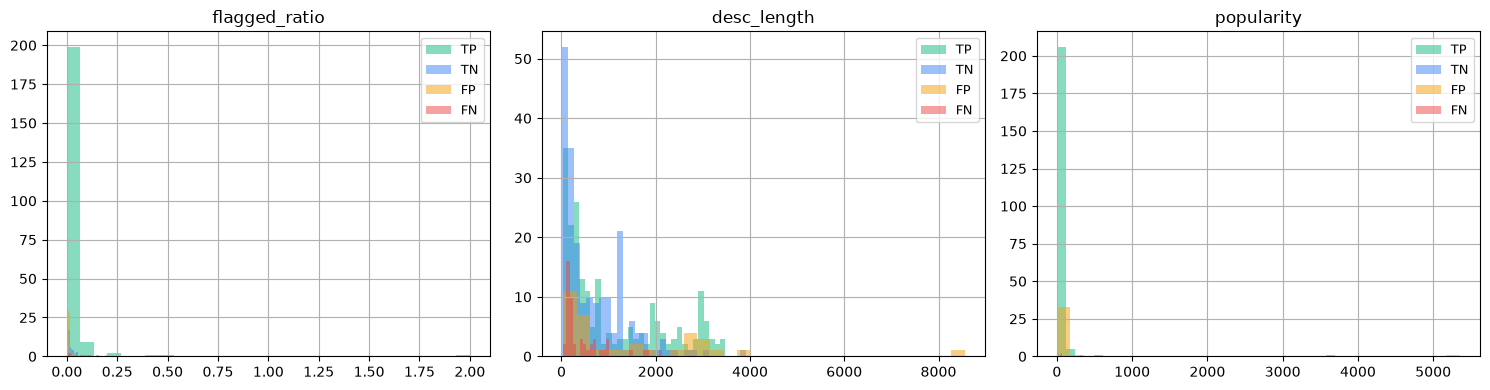

In [67]:
plot_cols = [c for c in ['flagged_ratio', 'desc_length', 'popularity'] if c in eval_df.columns]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
    if len(plot_cols) == 1: axes = [axes]
    for ax, col in zip(axes, plot_cols):
        for label, subset, color in [('TP', tp, '#10B981'), ('TN', tn, '#3B82F6'),
                                      ('FP', fp, '#F59E0B'), ('FN', fn, '#EF4444')]:
            subset[col].dropna().hist(ax=ax, alpha=0.5, label=label, bins=30, color=color)
        ax.set_title(col)
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
